In [2]:
import pandas as pd   #Usamos para ler a planilha, organizar colunas, filtrar dados e calcular médias.
import numpy as np    #Ela trabalha com números, cálculos matemáticos e listas numéricas.

import matplotlib.pyplot as plt  #Usamos para fazer gráficos de barras, linhas, dispersão e o gráfico do cotovelo.
import seaborn as sns   #deixa os gráficos mais bonitos e fáceis de visualizar.

from sklearn.cluster import KMeans  #usado para separar os Estados em grupos parecidos, chamados de clusters.
from sklearn.preprocessing import StandardScaler   #serve para padronizar os dados, deixando tudo na mesma escala antes de aplicar o K-Means.
from sklearn.metrics import silhouette_score   #mede se os grupos criados pelo K-Means ficaram bons ou não.

from mlxtend.frequent_patterns import apriori   #serve para encontrar padrões frequentes nos dados.
from mlxtend.frequent_patterns import association_rules #cria as regras de associação a partir dos padrões encontrados pelo Apriori.
from mlxtend.preprocessing import TransactionEncoder #transforma os dados em um formato que o Apriori consegue entender.

In [3]:
arquivo = 'domicilios num moradores brasil.xlsx'
                                        # esse bloco cria a variável "arquivo" e guarda o nome do arquivo Excel.
df = pd.read_excel(arquivo)             # nessa linha o pandas abre o excel e guarda os dados.

print(df.head())

                Ano       2022         2022       2022.1       2022.2  \
0         Município  1 morador  2 moradores  3 moradores  4 moradores   
1  Porto Velho (RO)       12.5          8.4          9.3          7.8   
2   Rio Branco (AC)       10.8          6.5          5.5          5.9   
3       Manaus (AM)       10.9          6.6          5.8          5.8   
4    Boa Vista (RR)       16.9          9.5          7.8          5.9   

        2022.3               2022.4       2025         2025       2025.1  \
0  5 moradores  6 moradores ou mais  1 morador  2 moradores  3 moradores   
1         13.3                 14.5       14.7            7          6.3   
2          9.6                 10.9        7.6          5.8          4.8   
3          9.6                  7.5        9.5            6          5.1   
4         10.4                 10.8        9.6          7.5          7.8   

        2025.2       2025.3               2025.4  
0  4 moradores  5 moradores  6 moradores ou mais  
1 

In [4]:
print(df.columns)

Index([   'Ano',   '2022',     2022, '2022.1', '2022.2', '2022.3', '2022.4',
         '2025',     2025, '2025.1', '2025.2', '2025.3', '2025.4'],
      dtype='object')


In [16]:
print(df.head(10))

                Ano       2022         2022       2022.1       2022.2  \
0         Município  1 morador  2 moradores  3 moradores  4 moradores   
1  Porto Velho (RO)       12.5          8.4          9.3          7.8   
2   Rio Branco (AC)       10.8          6.5          5.5          5.9   
3       Manaus (AM)       10.9          6.6          5.8          5.8   
4    Boa Vista (RR)       16.9          9.5          7.8          5.9   
5        Belém (PA)       11.8          8.5          7.1          6.8   
6       Macapá (AP)       17.7           11          7.1          8.7   
7       Palmas (TO)       15.6         14.1          9.7           10   
8     São Luís (MA)       12.9          7.8          7.5            8   
9     Teresina (PI)       18.4            9          7.6          9.1   

        2022.3               2022.4       2025         2025       2025.1  \
0  5 moradores  6 moradores ou mais  1 morador  2 moradores  3 moradores   
1         13.3                 14.5       14

In [17]:
# Procurar Estado de São Paulo

sp = df[df['Ano'].str.contains('(SP)', regex=False, na=False)]

print(sp)

               Ano 2022 2022 2022.1 2022.2 2022.3 2022.4 2025 2025 2025.1  \
20  São Paulo (SP)  6.4  4.8    3.8    5.1    9.1   12.5  6.9  4.6      4   

   2025.2 2025.3 2025.4  
20    5.3     13   16.3  


In [18]:
print(df['Ano'].head(50))

0               Município
1        Porto Velho (RO)
2         Rio Branco (AC)
3             Manaus (AM)
4          Boa Vista (RR)
5              Belém (PA)
6             Macapá (AP)
7             Palmas (TO)
8           São Luís (MA)
9           Teresina (PI)
10         Fortaleza (CE)
11             Natal (RN)
12       João Pessoa (PB)
13            Recife (PE)
14            Maceió (AL)
15           Aracaju (SE)
16          Salvador (BA)
17    Belo Horizonte (MG)
18           Vitória (ES)
19    Rio de Janeiro (RJ)
20         São Paulo (SP)
21          Curitiba (PR)
22     Florianópolis (SC)
23      Porto Alegre (RS)
24      Campo Grande (MS)
25            Cuiabá (MT)
26           Goiânia (GO)
27          Brasília (DF)
Name: Ano, dtype: str


In [19]:
# Ajustar nomes das colunas

df.columns = [
    'Estados',
    '2022_1_morador',
    '2022_2_moradores',
    '2022_3_moradores',
    '2022_4_moradores',
    '2022_5_moradores',
    '2022_6_ou_mais',
    '2025_1_morador',
    '2025_2_moradores',
    '2025_3_moradores',
    '2025_4_moradores',
    '2025_5_moradores',
    '2025_6_ou_mais'
]

print(df.head())

            Estados 2022_1_morador 2022_2_moradores 2022_3_moradores  \
0         Município      1 morador      2 moradores      3 moradores   
1  Porto Velho (RO)           12.5              8.4              9.3   
2   Rio Branco (AC)           10.8              6.5              5.5   
3       Manaus (AM)           10.9              6.6              5.8   
4    Boa Vista (RR)           16.9              9.5              7.8   

  2022_4_moradores 2022_5_moradores       2022_6_ou_mais 2025_1_morador  \
0      4 moradores      5 moradores  6 moradores ou mais      1 morador   
1              7.8             13.3                 14.5           14.7   
2              5.9              9.6                 10.9            7.6   
3              5.8              9.6                  7.5            9.5   
4              5.9             10.4                 10.8            9.6   

  2025_2_moradores 2025_3_moradores 2025_4_moradores 2025_5_moradores  \
0      2 moradores      3 moradores      4 

In [21]:
# Remove primeira linha da tabela.

df = df.iloc[1:]

# Resetar índices

df.reset_index(drop=True, inplace=True)

print(df.head())

           Estados 2022_1_morador 2022_2_moradores 2022_3_moradores  \
0  Rio Branco (AC)           10.8              6.5              5.5   
1      Manaus (AM)           10.9              6.6              5.8   
2   Boa Vista (RR)           16.9              9.5              7.8   
3       Belém (PA)           11.8              8.5              7.1   
4      Macapá (AP)           17.7               11              7.1   

  2022_4_moradores 2022_5_moradores 2022_6_ou_mais 2025_1_morador  \
0              5.9              9.6           10.9            7.6   
1              5.8              9.6            7.5            9.5   
2              5.9             10.4           10.8            9.6   
3              6.8             10.9           13.8            9.8   
4              8.7             13.9           10.3             13   

  2025_2_moradores 2025_3_moradores 2025_4_moradores 2025_5_moradores  \
0              5.8              4.8              5.5              9.5   
1           

In [23]:
# transformou os dados da planilha em números porque a primeira coluna é texto.

colunas_numericas = df.columns[1:]  # Converte para número e pega da posição 1 até o final

for coluna in colunas_numericas:        
    df[coluna] = pd.to_numeric(df[coluna])

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Estados           26 non-null     str    
 1   2022_1_morador    26 non-null     float64
 2   2022_2_moradores  26 non-null     float64
 3   2022_3_moradores  26 non-null     float64
 4   2022_4_moradores  26 non-null     float64
 5   2022_5_moradores  26 non-null     float64
 6   2022_6_ou_mais    26 non-null     float64
 7   2025_1_morador    26 non-null     float64
 8   2025_2_moradores  26 non-null     float64
 9   2025_3_moradores  26 non-null     float64
 10  2025_4_moradores  26 non-null     float64
 11  2025_5_moradores  26 non-null     float64
 12  2025_6_ou_mais    26 non-null     float64
dtypes: float64(12), str(1)
memory usage: 3.1 KB
None


In [25]:
print(df.head())               # por padrão mostra as 5 primeiras linhas da tabela.

           Estados  2022_1_morador  2022_2_moradores  2022_3_moradores  \
0  Rio Branco (AC)            10.8               6.5               5.5   
1      Manaus (AM)            10.9               6.6               5.8   
2   Boa Vista (RR)            16.9               9.5               7.8   
3       Belém (PA)            11.8               8.5               7.1   
4      Macapá (AP)            17.7              11.0               7.1   

   2022_4_moradores  2022_5_moradores  2022_6_ou_mais  2025_1_morador  \
0               5.9               9.6            10.9             7.6   
1               5.8               9.6             7.5             9.5   
2               5.9              10.4            10.8             9.6   
3               6.8              10.9            13.8             9.8   
4               8.7              13.9            10.3            13.0   

   2025_2_moradores  2025_3_moradores  2025_4_moradores  2025_5_moradores  \
0               5.8               4.8  

In [26]:
print(df.describe())    # mostra o resumo estatistico da tabela, como média, desvio padrão, mínimo e máximo.

       2022_1_morador  2022_2_moradores  2022_3_moradores  2022_4_moradores  \
count       26.000000         26.000000         26.000000         26.000000   
mean        11.276923          7.615385          6.484615          7.419231   
std          3.345960          2.463443          1.462243          1.934946   
min          5.100000          3.600000          3.500000          4.300000   
25%          9.450000          6.500000          5.500000          5.900000   
50%         11.250000          6.700000          6.750000          7.150000   
75%         12.825000          8.900000          7.450000          8.625000   
max         18.400000         14.100000          9.700000         11.300000   

       2022_5_moradores  2022_6_ou_mais  2025_1_morador  2025_2_moradores  \
count         26.000000       26.000000       26.000000         26.000000   
mean          12.923077       17.911538        9.115385          6.353846   
std            3.671328        5.970148        2.276962  

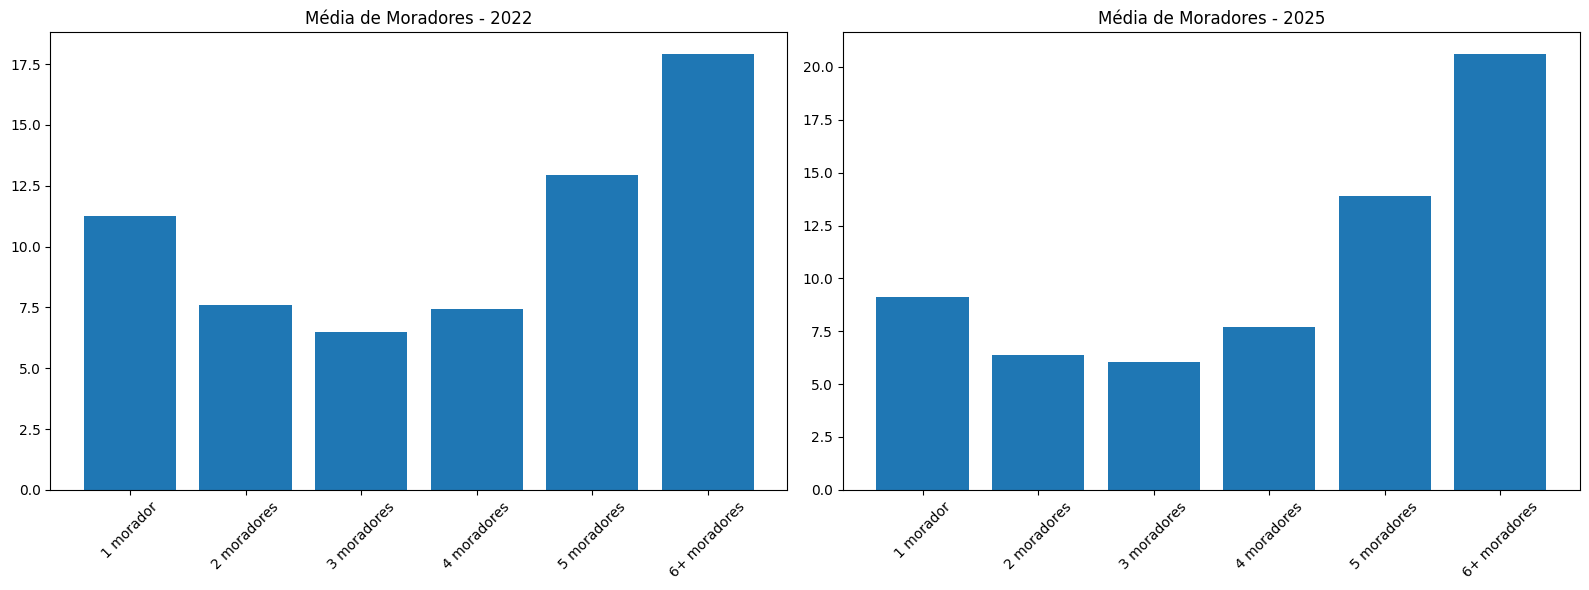

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))
                            # criados dois gráficos de barras lado a lado para comparar as médias de moradores
# 2022
medias_2022 = [
    df['2022_1_morador'].mean(),
    df['2022_2_moradores'].mean(),
    df['2022_3_moradores'].mean(),
    df['2022_4_moradores'].mean(),
    df['2022_5_moradores'].mean(),
    df['2022_6_ou_mais'].mean()
]

categorias = [
    '1 morador',
    '2 moradores',
    '3 moradores',
    '4 moradores',
    '5 moradores',
    '6+ moradores'
]

axes[0].bar(categorias, medias_2022)
axes[0].set_title('Média de Moradores - 2022')
axes[0].tick_params(axis='x', rotation=45)

# 2025
medias_2025 = [
    df['2025_1_morador'].mean(),
    df['2025_2_moradores'].mean(),
    df['2025_3_moradores'].mean(),
    df['2025_4_moradores'].mean(),
    df['2025_5_moradores'].mean(),
    df['2025_6_ou_mais'].mean()
]

axes[1].bar(categorias, medias_2025)
axes[1].set_title('Média de Moradores - 2025')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
X = df[colunas_numericas]        # seleciona apenas as colunas numéricas para o K-Means

In [32]:
scaler = StandardScaler()   # ferramenta do Scikit-Learn que ajusta os números para uma escala parecida.

X_padronizado = scaler.fit_transform(X)

C:\Users\drubi\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\drubi\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\drubi\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\drubi\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_

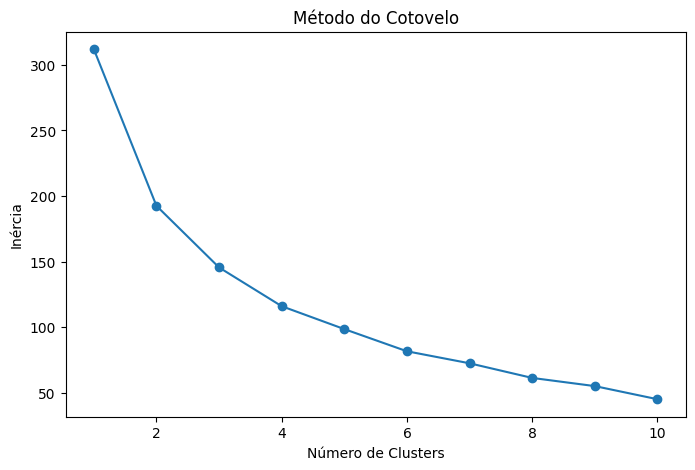

In [35]:
inercias = []                        # A inércia mede o quão “organizados” os grupos ficaram.      
                                     # serve para descobrir quantos grupos (clusters) o K-Means deve usar.
                                     # Criao gráfico do Método do Cotovelo.

for k in range(1, 11):
    modelo = KMeans(                              # prepara o algoritmo k-means para testar.
        n_clusters=k,                             # quantos grupos serão testados
        random_state=42,                          # mantém os resultados consistentes em cada execução
        n_init=10                                 # testa 10 vezes e pega o melhor resultado
    )

    modelo.fit(X_padronizado)                     # O algoritmo analisa os dados padronizados.

    inercias.append(modelo.inertia_)              #  a inércia mede o quão “organizados” os grupos ficaram.

plt.figure(figsize=(8,5))                         # tamanho do gráfico do Método do Cotovelo

plt.plot(range(1,11), inercias, marker='o')       # testa 10 clusters (a curva do Método do Cotovelo).

plt.xlabel('Número de Clusters')
plt.ylabel('Inércia')
                                                # "escolhido o valor de 3 clusters.”
plt.title('Método do Cotovelo')

plt.show()

In [ ]:
# =========================
# APRIORI - FUNÇÃO
# =========================

def rodar_apriori(base, nome_base):
    dados = base.copy()
    
    for coluna in colunas_numericas:
        media = dados[coluna].mean()
        dados[coluna] = dados[coluna].apply(
            lambda x: f'{coluna}_Alto' if x >= media else f'{coluna}_Baixo'
        )
    
    transacoes = dados[colunas_numericas].values.tolist()
    
    te = TransactionEncoder()
    te_array = te.fit(transacoes).transform(transacoes)
    basket = pd.DataFrame(te_array, columns=te.columns_)
    
    frequentes = apriori(
        basket,
        min_support=0.2,
        use_colnames=True
    )
    
    regras = association_rules(
        frequentes,
        metric='confidence',
        min_threshold=0.7
    )
    
    regras = regras.sort_values(by='lift', ascending=False)
    regras['Base'] = nome_base
    
    return regras

In [ ]:
# Filtrar apenas São Paulo

sp = df[df['Estados'].str.contains('(SP)', regex=False)]

# Mostrar

print(sp)

         Municipio  2022_1_morador  2022_2_moradores  2022_3_moradores  \
19  São Paulo (SP)             6.4               4.8               3.8   

    2022_4_moradores  2022_5_moradores  2022_6_ou_mais  2025_1_morador  \
19               5.1               9.1            12.5             6.9   

    2025_2_moradores  2025_3_moradores  2025_4_moradores  2025_5_moradores  \
19               4.6               4.0               5.3              13.0   

    2025_6_ou_mais  
19            16.3  


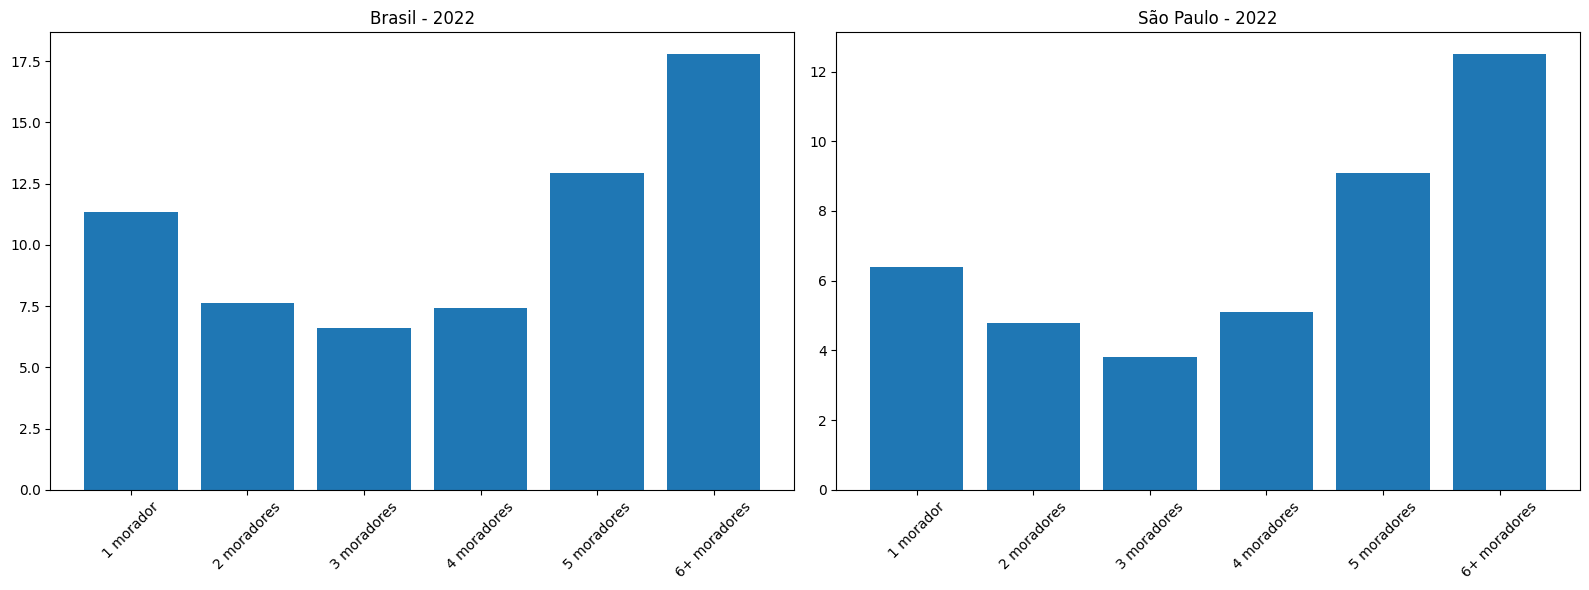

In [ ]:
# Médias Brasil

brasil_2022 = [
    df['2022_1_morador'].mean(),
    df['2022_2_moradores'].mean(),
    df['2022_3_moradores'].mean(),
    df['2022_4_moradores'].mean(),
    df['2022_5_moradores'].mean(),
    df['2022_6_ou_mais'].mean()
]

# Dados São Paulo

sp_2022 = [
    sp['2022_1_morador'].mean(),
    sp['2022_2_moradores'].mean(),
    sp['2022_3_moradores'].mean(),
    sp['2022_4_moradores'].mean(),
    sp['2022_5_moradores'].mean(),
    sp['2022_6_ou_mais'].mean()
]

categorias = [
    '1 morador',
    '2 moradores',
    '3 moradores',
    '4 moradores',
    '5 moradores',
    '6+ moradores'
]

fig, axes = plt.subplots(1, 2, figsize=(16,6))

# Brasil
axes[0].bar(categorias, brasil_2022)
axes[0].set_title('Brasil - 2022')
axes[0].tick_params(axis='x', rotation=45)

# São Paulo
axes[1].bar(categorias, sp_2022)
axes[1].set_title('São Paulo - 2022')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

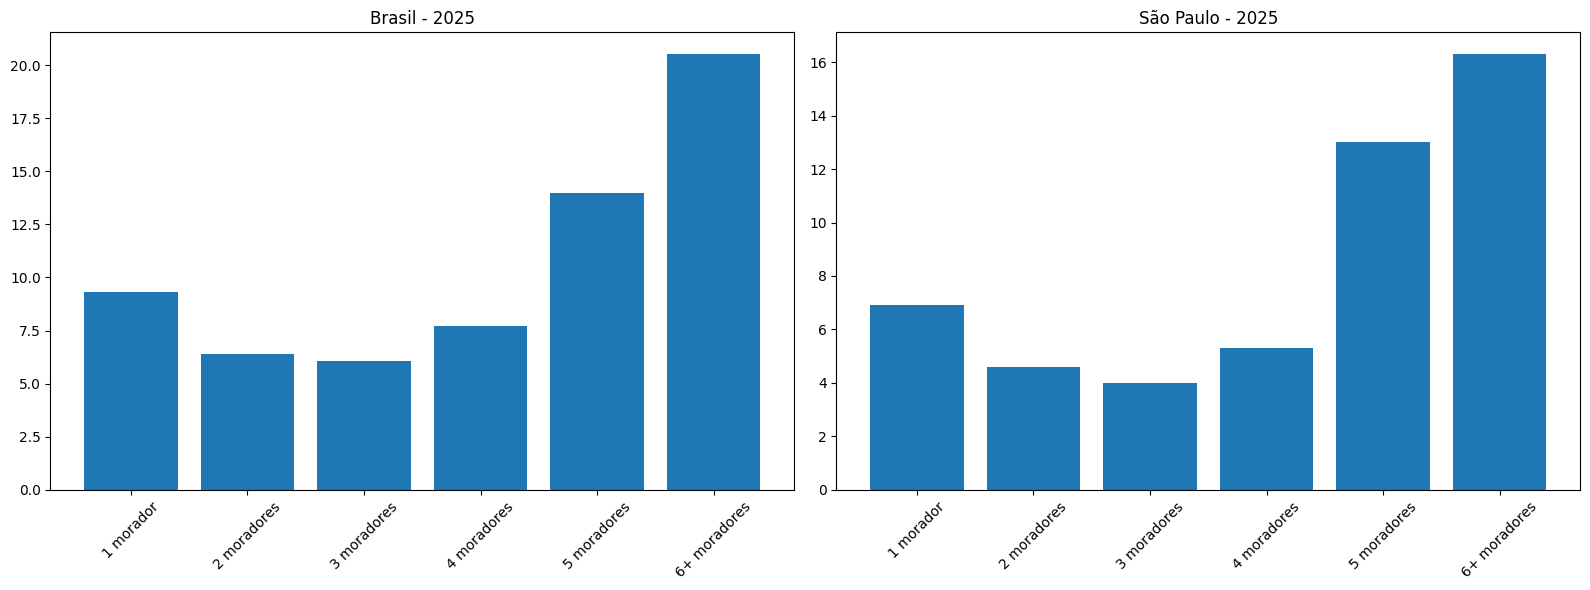

In [ ]:
# Médias Brasil

brasil_2025 = [
    df['2025_1_morador'].mean(),
    df['2025_2_moradores'].mean(),
    df['2025_3_moradores'].mean(),
    df['2025_4_moradores'].mean(),
    df['2025_5_moradores'].mean(),
    df['2025_6_ou_mais'].mean()
]

# Dados São Paulo

sp_2025 = [
    sp['2025_1_morador'].mean(),
    sp['2025_2_moradores'].mean(),
    sp['2025_3_moradores'].mean(),
    sp['2025_4_moradores'].mean(),
    sp['2025_5_moradores'].mean(),
    sp['2025_6_ou_mais'].mean()
]

categorias = [
    '1 morador',
    '2 moradores',
    '3 moradores',
    '4 moradores',
    '5 moradores',
    '6+ moradores'
]

fig, axes = plt.subplots(1, 2, figsize=(16,6))

# Brasil
axes[0].bar(categorias, brasil_2025)
axes[0].set_title('Brasil - 2025')
axes[0].tick_params(axis='x', rotation=45)

# São Paulo
axes[1].bar(categorias, sp_2025)
axes[1].set_title('São Paulo - 2025')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# =========================
# K-MEANS
# =========================

X = df[colunas_numericas]

scaler = StandardScaler()
X_padronizado = scaler.fit_transform(X)

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_padronizado)

score = silhouette_score(X_padronizado, df['Cluster'])

print("Silhouette Score:", score)
print(df[['Estados', 'Cluster']])

Silhouette Score: 0.2712398309140975
              Municipio  Cluster
0      Porto Velho (RO)        2
1       Rio Branco (AC)        0
2           Manaus (AM)        0
3        Boa Vista (RR)        2
4            Belém (PA)        2
5           Macapá (AP)        2
6           Palmas (TO)        1
7         São Luís (MA)        2
8         Teresina (PI)        2
9        Fortaleza (CE)        0
10           Natal (RN)        1
11     João Pessoa (PB)        0
12          Recife (PE)        1
13          Maceió (AL)        0
14         Aracaju (SE)        1
15        Salvador (BA)        1
16  Belo Horizonte (MG)        0
17         Vitória (ES)        1
18  Rio de Janeiro (RJ)        0
19       São Paulo (SP)        0
20        Curitiba (PR)        0
21   Florianópolis (SC)        1
22    Porto Alegre (RS)        0
23    Campo Grande (MS)        0
24          Cuiabá (MT)        1
25         Goiânia (GO)        0
26        Brasília (DF)        0


C:\Users\drubi\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


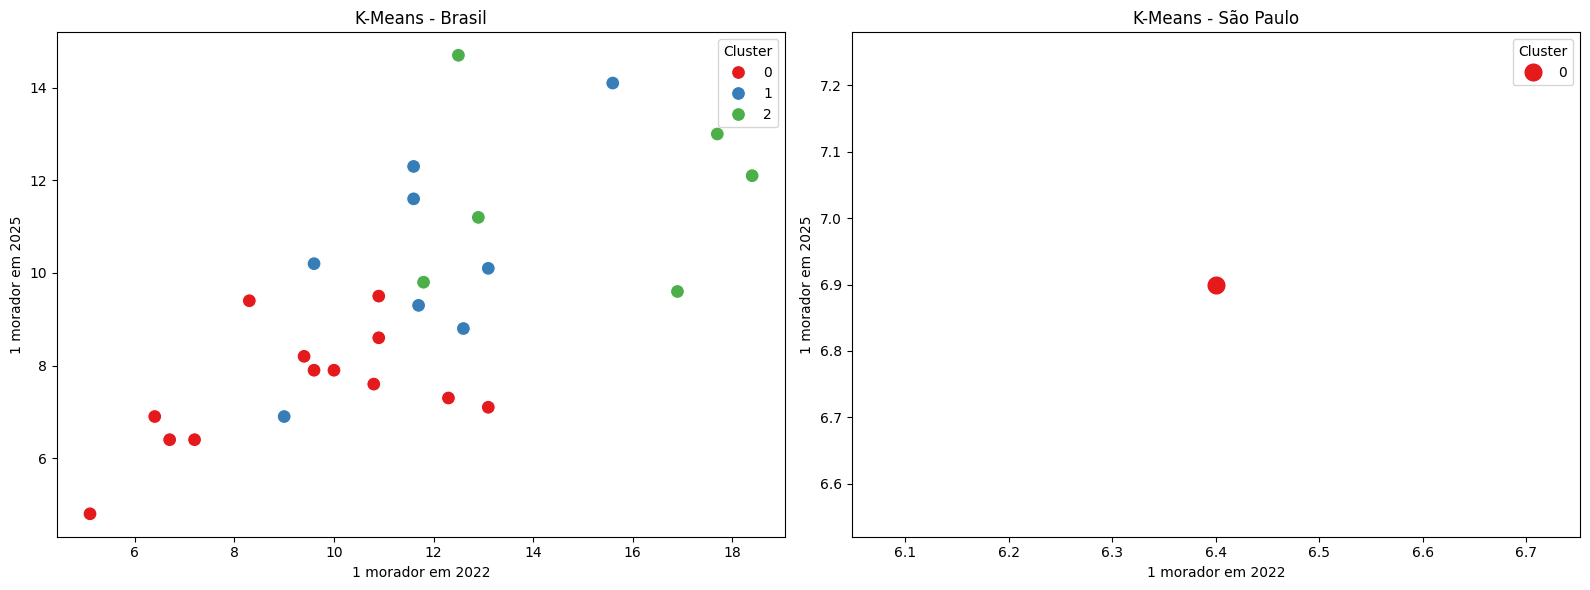

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))

sns.scatterplot(
    data=df,
    x='2022_1_morador',
    y='2025_1_morador',
    hue='Cluster',
    palette='Set1',
    s=100,
    ax=axes[0]
)

axes[0].set_title('K-Means - Brasil')
axes[0].set_xlabel('1 morador em 2022')
axes[0].set_ylabel('1 morador em 2025')

sp = df[df['Estados'].str.contains('(SP)', regex=False)]

sns.scatterplot(
    data=sp,
    x='2022_1_morador',
    y='2025_1_morador',
    hue='Cluster',
    palette='Set1',
    s=200,
    ax=axes[1]
)

axes[1].set_title('K-Means - São Paulo')
axes[1].set_xlabel('1 morador em 2022')
axes[1].set_ylabel('1 morador em 2025')

plt.tight_layout()
plt.show()

In [ ]:
# =========================
# APRIORI
# =========================

apriori_df = df.copy()

for coluna in colunas_numericas:
    media = apriori_df[coluna].mean()
    
    apriori_df[coluna] = apriori_df[coluna].apply(
        lambda x: f'{coluna}_Alto' if x >= media else f'{coluna}_Baixo'
    )

transacoes = apriori_df[colunas_numericas].values.tolist()

te = TransactionEncoder()
te_array = te.fit(transacoes).transform(transacoes)

basket = pd.DataFrame(te_array, columns=te.columns_)

frequentes = apriori(
    basket,
    min_support=0.2,
    use_colnames=True
)

regras = association_rules(
    frequentes,
    metric='confidence',
    min_threshold=0.7
)

regras = regras.sort_values(by='lift', ascending=False)

print(regras[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

                                             antecedents  \
33533  frozenset({2025_2_moradores_Alto, 2025_6_ou_ma...   
52370  frozenset({2025_6_ou_mais_Baixo, 2022_5_morado...   
52396  frozenset({2025_2_moradores_Baixo, 2022_6_ou_m...   
17089  frozenset({2022_2_moradores_Alto, 2025_6_ou_ma...   
17102  frozenset({2022_1_morador_Alto, 2025_2_morador...   
46014  frozenset({2022_5_moradores_Baixo, 2022_3_mora...   
46013  frozenset({2022_5_moradores_Baixo, 2022_3_mora...   
17103  frozenset({2022_1_morador_Alto, 2022_2_morador...   
17106  frozenset({2022_1_morador_Alto, 2025_2_morador...   
22773  frozenset({2025_2_moradores_Alto, 2025_6_ou_ma...   

                                             consequents   support  \
33533  frozenset({2022_1_morador_Alto, 2025_1_morador...  0.222222   
52370  frozenset({2025_2_moradores_Baixo, 2022_6_ou_m...  0.222222   
52396  frozenset({2022_3_moradores_Baixo, 2025_5_mora...  0.222222   
17089  frozenset({2022_1_morador_Alto, 2025_1_morador...  0

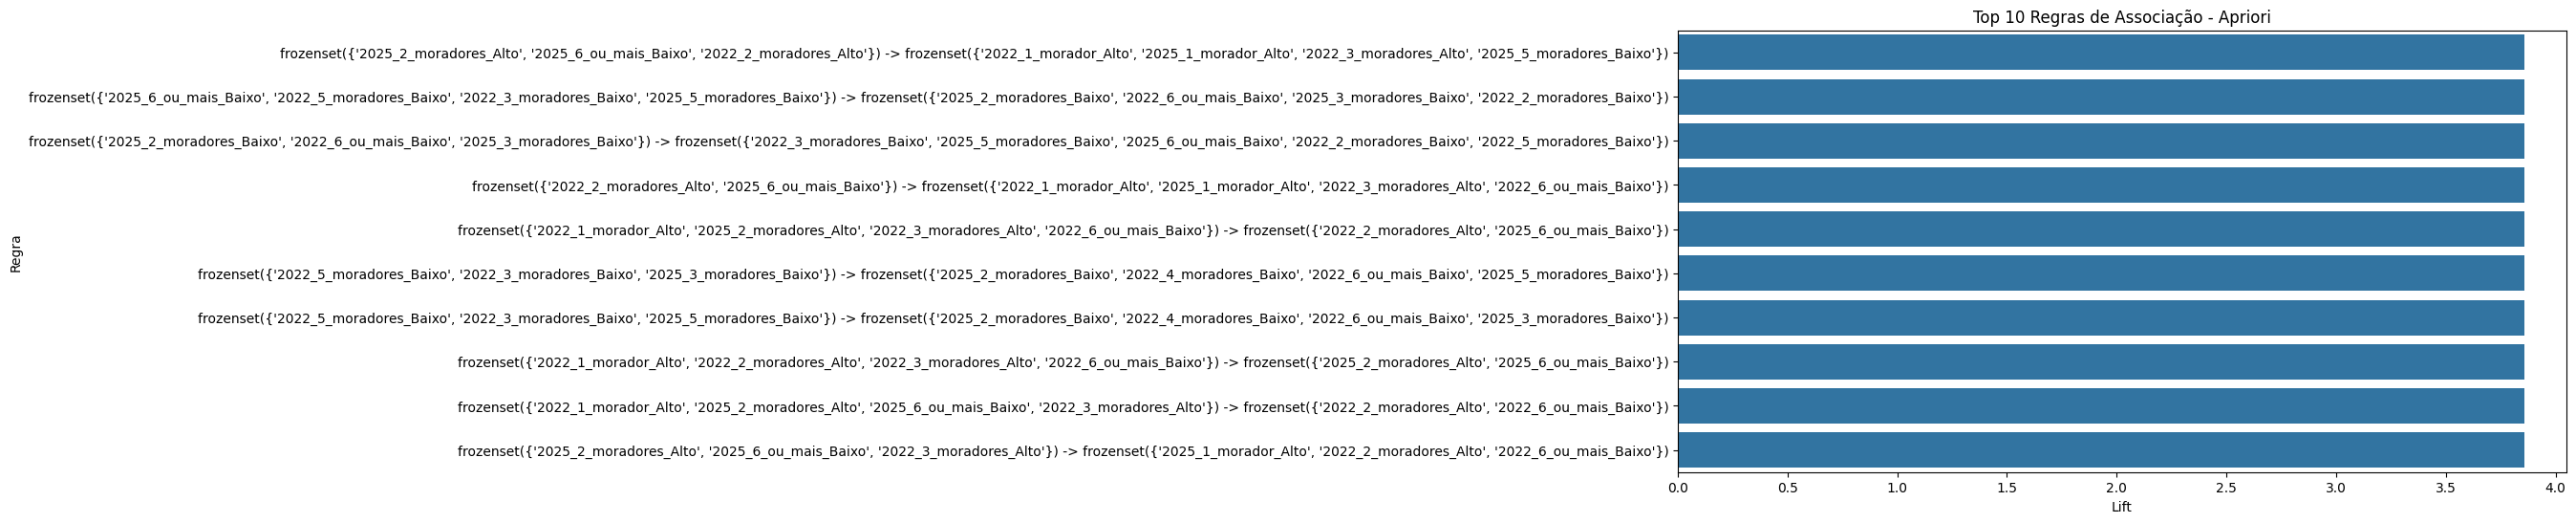

In [ ]:
top10_regras = regras.head(10).copy()

top10_regras['regra'] = (
    top10_regras['antecedents'].astype(str) 
    + ' -> ' 
    + top10_regras['consequents'].astype(str)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_regras,
    x='lift',
    y='regra'
)

plt.title('Top 10 Regras de Associação - Apriori')
plt.xlabel('Lift')
plt.ylabel('Regra')

plt.show()